<a href="https://colab.research.google.com/github/farmanali11/core-ai-learning/blob/main/data_augementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf


from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
dataset_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'

data_dir = tf.keras.utils.get_file('flower-photos',origin= dataset_url,cache_dir='.',untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [3]:
data_dir

'./datasets/flower-photos'

In [4]:
import pathlib
data_dir = pathlib.Path(data_dir) / 'flower_photos'
data_dir

PosixPath('datasets/flower-photos/flower_photos')

In [5]:
print(os.listdir(data_dir))

['roses', 'tulips', 'daisy', 'dandelion', 'sunflowers', 'LICENSE.txt']


In [6]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('datasets/flower-photos/flower_photos/roses/2675221506_5286c0595f.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/roses/3265902330_d8b1e44545.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/roses/3871586333_5a708d5cf4_n.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/roses/4558025386_2c47314528.jpg')]

In [7]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [8]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('datasets/flower-photos/flower_photos/roses/2675221506_5286c0595f.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/roses/3265902330_d8b1e44545.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/roses/3871586333_5a708d5cf4_n.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/roses/4558025386_2c47314528.jpg')]

In [9]:

# image_count = len(list(data_dir.glob('*/*.jpg')))
# print(image_count)

In [10]:
# import os

# # List the contents of the data_dir to understand its structure
# print(os.listdir(data_dir))

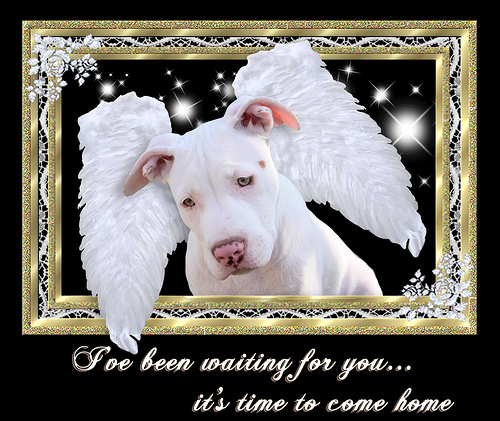

In [11]:
roses = list(data_dir.glob('roses/*.jpg'))
PIL.Image.open(str(roses[1]))

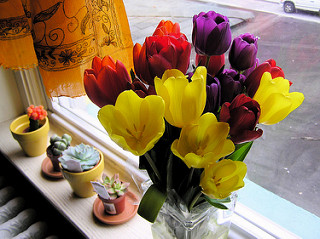

In [12]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[30]))

In [13]:
flowers_images_dict = {
    'roses':list(data_dir.glob('tulips/*')),
    'daisy':list(data_dir.glob('daisy/*')),
    'dandelion':list(data_dir.glob('dandelion/*')),
    'sunflowers':list(data_dir.glob('sunflowers/*')),
    'tulips':list(data_dir.glob('tulips/*')),
}

In [14]:
flowers_labels_dict={
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}

In [15]:
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower-photos/flower_photos/tulips/251811158_75fa3034ff.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/tulips/14275234071_6e6f473356.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/tulips/3511776685_3635087b12_n.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/tulips/5674170543_73e3f403fb.jpg'),
 PosixPath('datasets/flower-photos/flower_photos/tulips/14074147406_7ab87aec79_n.jpg')]

In [16]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [17]:
img.shape

(376, 500, 3)

In [18]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [19]:
X,y = [],[]
for flower_name ,images in flowers_images_dict.items():
  for image in images:
    img = cv2.imread(str(image))
    resized_img = cv2.resize(img,(180,180))
    X.append(resized_img)
    y.append(flowers_labels_dict[flower_name])

In [20]:
X = np.array(X)
y = np.array(y)

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)



In [22]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [23]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])


model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(X_train_scaled,y_train,epochs=30)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.3960 - loss: 1.4195
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5200 - loss: 1.0856
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5893 - loss: 0.9346
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6395 - loss: 0.8043
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6987 - loss: 0.6331
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7485 - loss: 0.4903
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7705 - loss: 0.4038
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8015 - loss: 0.3476
Epoch 9/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8112 - loss: 0.3045
Epoch 10/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8192 - loss: 0.2854
Epoch 11/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8192 - loss: 0.2748
Epoch 12/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy

In [24]:
model.evaluate(X_test_scaled,y_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4420 - loss: 2.0424


[2.042417526245117, 0.44200626015663147]

In [26]:
predictions = model.predict(X_test_scaled)
predictions

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


array([[  3.7825193,  -3.0179663,  -1.7303199, -15.891544 ,   7.0407314],
       [  5.9928207,  -9.16255  ,  -5.860771 , -16.754438 ,   4.854971 ],
       [ 11.582716 , -11.421475 , -18.942411 , -15.359804 ,  14.581134 ],
       ...,
       [  7.752344 ,  -6.323609 , -14.497914 ,  -9.073335 ,   7.644227 ],
       [ -6.770434 ,   6.247639 ,  10.955422 , -13.186325 ,  -7.389379 ],
       [  5.664979 ,  -5.675754 ,  -4.3455305, -13.538511 ,   6.7953973]],
      dtype=float32)

In [28]:
score = tf.nn.softmax(predictions[0])
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(np.argmax(score), 100 * np.max(score)))

This image most likely belongs to 4 with a 96.28 percent confidence.


In [29]:
np.argmax(score)

np.int64(4)

In [30]:
y_test[0]

np.int64(0)

In [33]:
img_height = 180
img_width = 180

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal",input_shape =(img_height,img_width,3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1)

    ]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


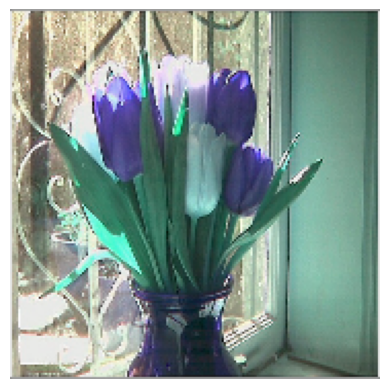

In [34]:
plt.axis('off')
plt.imshow(X[0])

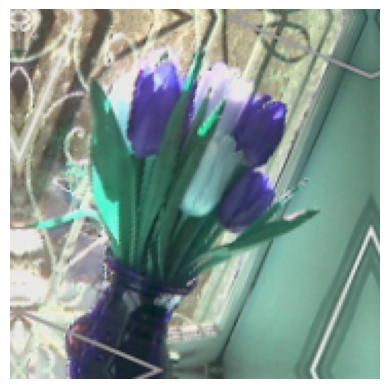

In [35]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype('uint8'))

In [36]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])


model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(X_train_scaled,y_train,epochs=30)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.3971 - loss: 1.3601
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.5197 - loss: 1.0905
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5772 - loss: 0.9931
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5879 - loss: 0.9366
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.6238 - loss: 0.8814
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6277 - loss: 0.8420
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6297 - loss: 0.8256
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6479 - loss: 0.7795
Epoch 9/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6444 - loss: 0.7641
Epoch 10/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6701 - loss: 0.7369
Epoch 11/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.6594 - loss: 0.7164
Epoch 12/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy:

In [37]:
model.evaluate(X_test_scaled,y_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5820 - loss: 0.8572


[0.8571710586547852, 0.5820271968841553]

Although in our case the **accuracy score is not as good as it should be**, my main purpose was to differentiate the **importance of augmentation and dropout layers**, specifically how they help us **increase accuracy** and **avoid the overfitting case**.

**Regards**
